# **DIPLOMSKI RAD - BLOKATOR NEŽELJENOG SADRŽAJA KORIŠTENJEM MODELA STROJNOG UČENJA**

## Uvoz potrebnih biblioteka

In [1]:
pip install pandas matplotlib seaborn networkx scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\Marta\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests
import ast

import joblib

import json
import urllib.parse
import networkx as nx

from sklearn.preprocessing import LabelEncoder, RobustScaler
from urllib.parse import urlparse, urlunparse
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import xgboost as xgb

# **Uvoz podataka**

In [54]:
rawDf = pd.read_json('datasetNetwork.json')['data']
df = pd.DataFrame(rawDf.tolist())
df.head(2)

,url,mainPageUrl,method,resourceType,initiatorType,initiatorUrl,domainEntropy,urlEntropy,isThirdParty,reqHeaderCount,...,characterContinuity,isTrackingParam,status,mimeType,hassizeBytes,setCookies,resHeaderCount,latency,isPotentialPixel,resHeader
0,https://wordpress.org/,https://wordpress.org/,GET,document,other,NaN,3.026987,3.538311,False,14,...,0.7143,False,200,text/html; charset=UTF-8,0,False,11,541,False,"{'alt-svc': 'clear', 'content-encoding': 'br',..."
1,https://i0.wp.com/wordpress.org/files/2026/06/...,https://wordpress.org/,GET,image,parser,https://wordpress.org/,2.947703,4.616699,True,14,...,0.2188,False,200,image/webp,26204,False,17,67,False,"{'access-control-allow-methods': 'GET, HEAD', ..."


In [55]:
with open('datasetGraph.json', encoding='utf-8') as f:
    dom_data = json.load(f)['pages']

direct_connections = []
subtree_sizes = []
is_attached = []

# 2. Iterate through each network request and match it against the page's DOM Graph
for _, row in df.iterrows():
    page_url = row['mainPageUrl']
    req_url = row['url']

    # Locate the DOM graph for this specific website URL
    dom_item = next((item for item in dom_data if item['mainPageUrl'] == page_url), None)
    if not dom_item:
        direct_connections.append(0)
        subtree_sizes.append(0)
        is_attached.append(False)
        continue

    graph_data = dom_item['graph']

    # Build a directed graph of the DOM structure
    G = nx.DiGraph()
    matched_node_ids = []

    for node in graph_data['nodes']:
        G.add_node(node['id'])
        # Match against resolvedUrls array (new format) or resolvedUrl (old format)
        node_urls = node.get('resolvedUrls', [])
        if not node_urls and node.get('resolvedUrl'):
            node_urls = [node['resolvedUrl']]
        if req_url in node_urls:
            matched_node_ids.append(node['id'])

    for edge in graph_data['edges']:
        if edge['relation'] == 'CHILD_OF':
            G.add_edge(edge['source'], edge['target'])

    # --- Calculate Features ---
    direct_count = len(matched_node_ids)
    direct_connections.append(direct_count)
    is_attached.append(direct_count > 0)

    # Trace the unique descendant elements reachable from all matching DOM nodes
    descendants = set()
    for node_id in matched_node_ids:
        if node_id in G:
            descendants.update(nx.descendants(G, node_id))

    subtree_sizes.append(len(descendants))

# 3. Add features to your DataFrame
df['directDomConnections'] = direct_connections
df['domSubtreeSize'] = subtree_sizes
df['isAttachedToDom'] = is_attached


# **Labeliranje zahtjeva i odgovora**

Prilikom pregleda podataka primjećeno je da se nisu svi podaci dobro klasificirali (to jest ima mnogo lažno negativnih podataka). Stoga će se ovdje preuzeti sve korištene filter liste i ponovno dodati njihova prava labela.


In [4]:
filter_lists = [
    ("EasyList cookies", "https://secure.fanboy.co.nz/fanboy-cookiemonster.txt"),
    ("EasyPrivacy", "https://easylist-downloads.adblockplus.org/easyprivacy_nointernational.txt"),
    ("Fanboy's annoyance list", "https://easylist.to/easylist/fanboy-annoyance.txt"),
    ("ADVOID Full List", "https://raw.githubusercontent.com/the-advoid/ad-void/refs/heads/main/AdVoid.Full.txt"),
    ("DandelionSprout", "https://raw.githubusercontent.com/DandelionSprout/adfilt/master/LegitimateURLShortener.txt"),
    ("Pete Lowe's Blocklist", "https://pgl.yoyo.org/adservers/serverlist.php?hostformat=adblockplus&showintro=1&mimetype=plaintext"),
    ("AdGuard Tracking protection List", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_3_Spyware/filter.txt"),
    ("AdGuard URL tracking list", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_17_TrackParam/filter.txt"),
    ("AdGuard Annoyance Cookies", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_18_Annoyances_Cookies/filter.txt"),
    ("Adguard Popups", "https://raw.githubusercontent.com/AdguardTeam/FiltersRegistry/master/filters/filter_19_Annoyances_Popups/filter.txt"),
    ("Adguard base filter + EasyList", "https://filters.adtidy.org/extension/ublock/filters/2.txt")
]

In [56]:
def parseFilterListRules(text):
    rules = text.split('\n')
    ruleCleanupRegex = r"^([^$#\n!]+)"

    substringMatch = set()  # For domain rules and strings
    exceptions = set()      # For @@ rules
    regexMatch = set()      # For /regex/ rules


    for rule in rules:
        strip = rule.strip()
        if not strip or any(strip.startswith(x) for x in ('!', '#', '[')): continue
        if '##' in strip or '#@#' in strip: continue

        if len(strip) <= 3: continue

        # 1. Handle Exceptions (Whitelist)
        if strip.startswith('@@'):
            exceptions.add(strip)
            continue


        # 2. Handle Regex Rules
        elif (strip.startswith('/') and strip.endswith('/') and len(strip) > 1) or "\\" in strip:
            regexMatch.add(strip)
            continue

        else:
          substringMatch.add(strip)
          continue


    return exceptions, regexMatch, substringMatch

In [57]:
exceptions = set()
regexMatch = set()
substringMatch = set()

for name, url in filter_lists:
    try:
        response = requests.get(url)
        response.raise_for_status() 
        print(f"Fetched data from {name}.txt")
        # Parse the rules
        new_exceptions, new_regex, new_substrings = parseFilterListRules(response.text)

        exceptions.update(new_exceptions)
        regexMatch.update(new_regex)
        substringMatch.update(new_substrings)

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from {url}: {e}")

Fetched data from EasyList cookies.txt
Fetched data from EasyPrivacy.txt
Fetched data from Fanboy's annoyance list.txt
Fetched data from ADVOID Full List.txt
Fetched data from DandelionSprout.txt
Fetched data from Pete Lowe's Blocklist.txt
Fetched data from AdGuard Tracking protection List.txt
Fetched data from AdGuard URL tracking list.txt
Fetched data from AdGuard Annoyance Cookies.txt
Fetched data from Adguard Popups.txt
Fetched data from Adguard base filter + EasyList.txt


In [58]:
copy = substringMatch.copy()
for i in exceptions:
  if i in copy:
    substringMatch.remove(i)

In [ ]:
pip install adblock

In [59]:
from adblock import Engine, FilterSet
fs = FilterSet()

fs.add_filters(list(exceptions))
fs.add_filters(list(substringMatch))
fs.add_filters(list(regexMatch))

engine = Engine(fs, optimize=True)

Sada primjenjujemo prikupljene filter liste na prikupljeni skup podataka.

In [60]:
df["label"] = False
for i, row in df.iterrows():
  result = engine.check_network_urls(
    url=row["url"],
    source_url=row["mainPageUrl"],
    request_type=row["resourceType"]
    )
  df.at[i, "label"] = result.matched

In [61]:
df.to_csv('df_labeled.csv', index=False)

# **Vizualizacija podataka**

In [62]:
numericalCols = df.select_dtypes(include=['number']).columns.tolist()

In [63]:
cols = df.columns.tolist()
categCols = []

for i in cols:
  if i not in numericalCols:
    categCols.append(i)

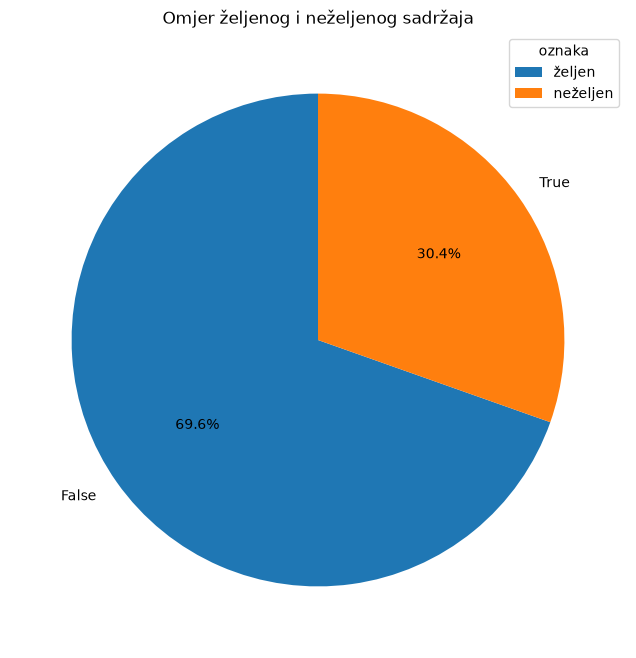

In [64]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Omjer željenog i neželjenog sadržaja')

legend_labels = ['neželjen' if label == 1 else 'željen' for label in label_counts.index]
plt.legend(legend_labels, title="oznaka")

plt.show()

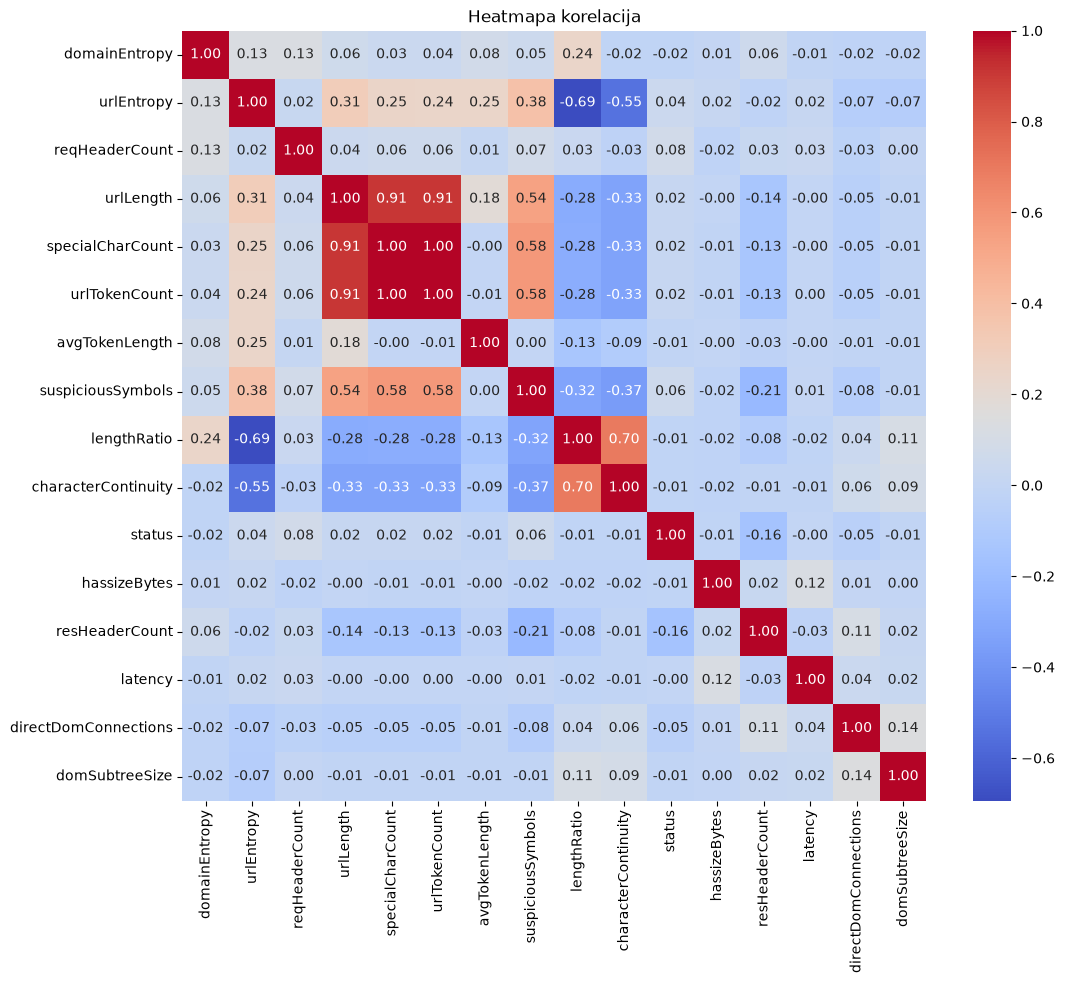

In [65]:
correlation_matrix = df[numericalCols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmapa korelacija")
plt.show()

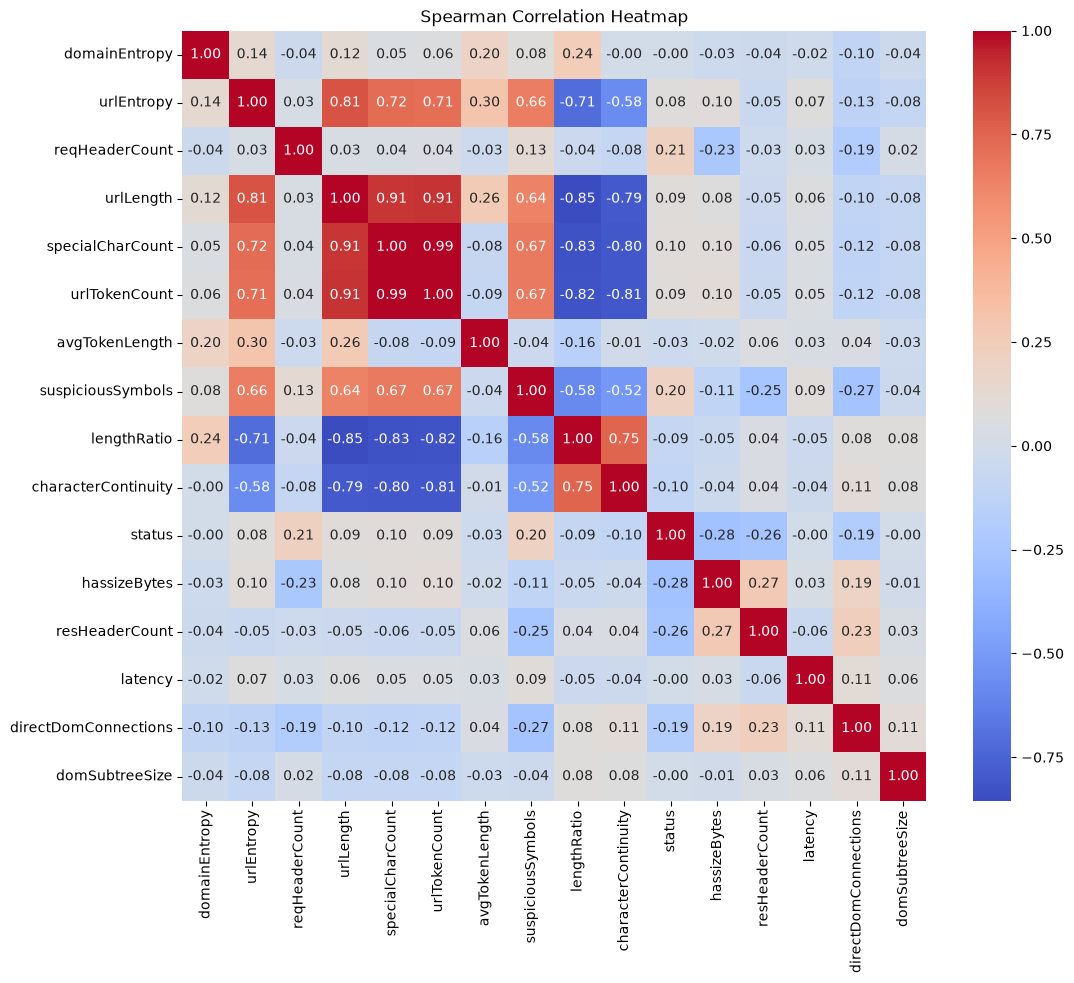

In [66]:
correlation_matrix = df[numericalCols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

In [67]:
def show_categ_graph(el, label):
  plt.figure(figsize=(10, 6))
  sns.countplot(data=df, x=el, hue=label, palette='viridis')
  plt.title(f'Distribucija {el} i {label}')
  plt.xlabel(el)
  plt.ylabel('Count')
  plt.legend(title='oznake', labels=['Željen', 'Neželjen'])
  plt.show()

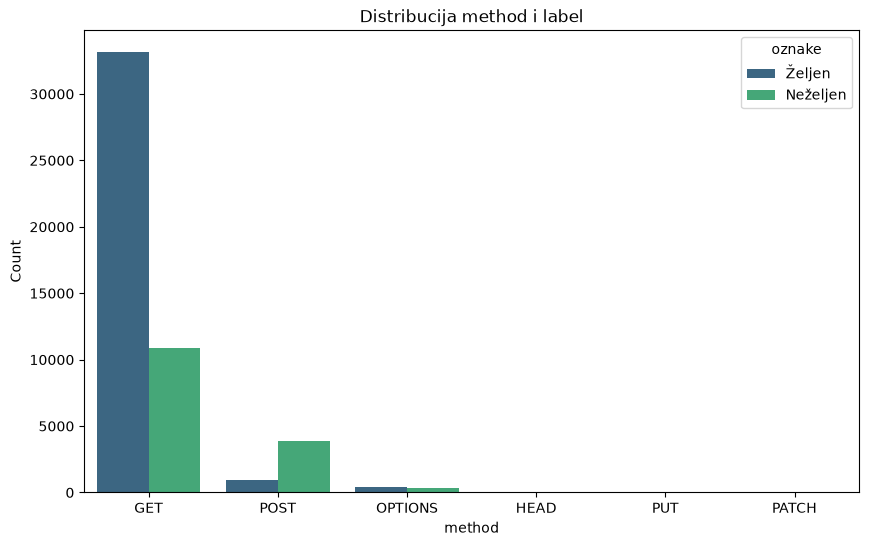

In [68]:
show_categ_graph("method", "label")

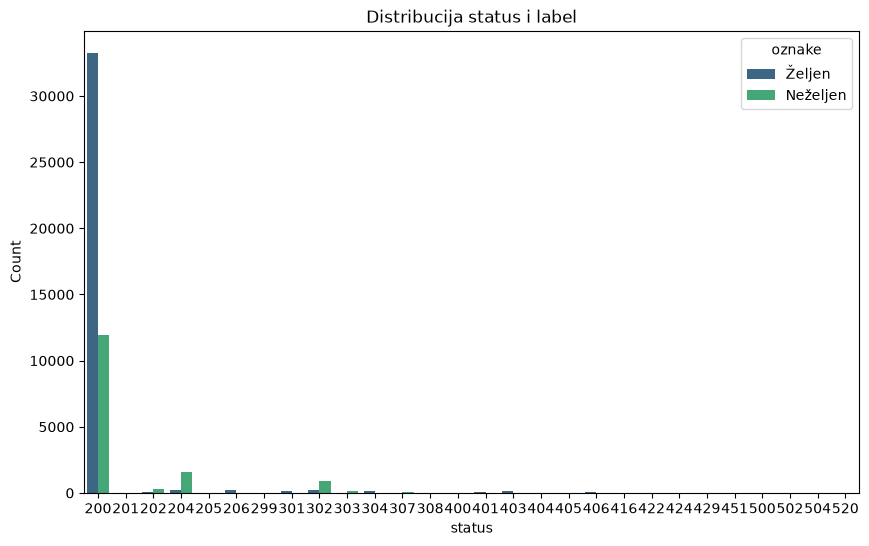

In [69]:
show_categ_graph("status", "label")

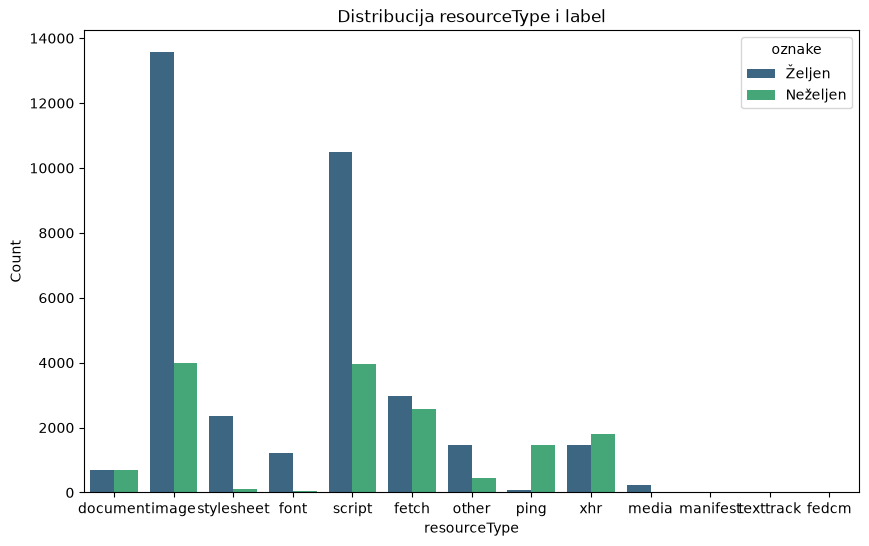

In [70]:
show_categ_graph("resourceType", "label")

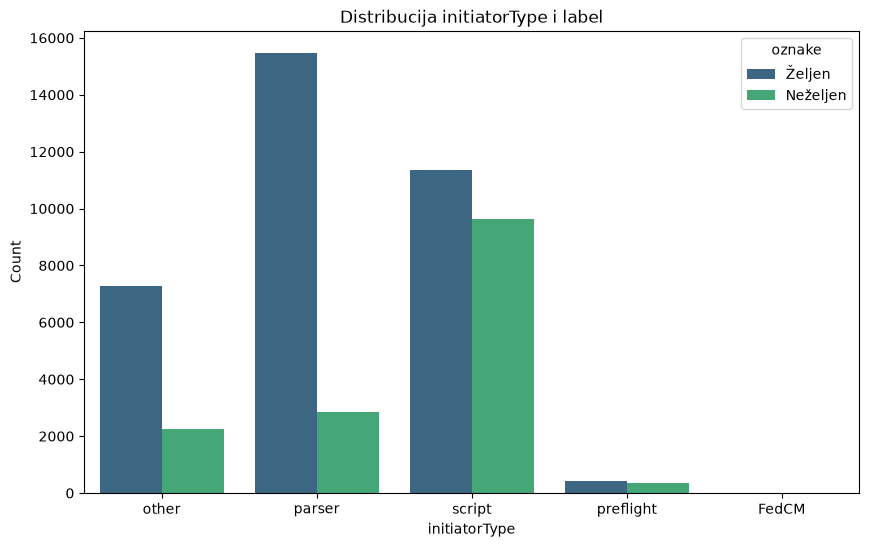

In [71]:
show_categ_graph("initiatorType", "label")

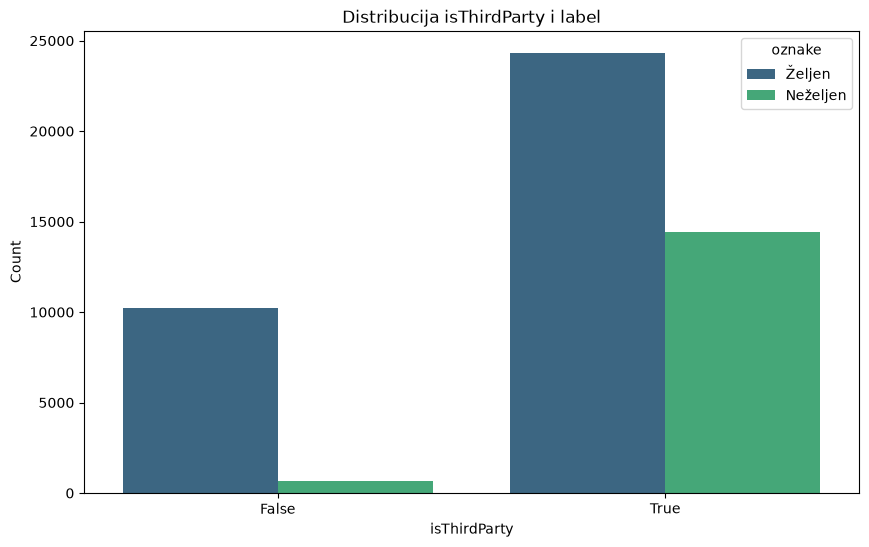

In [72]:
show_categ_graph("isThirdParty", "label")

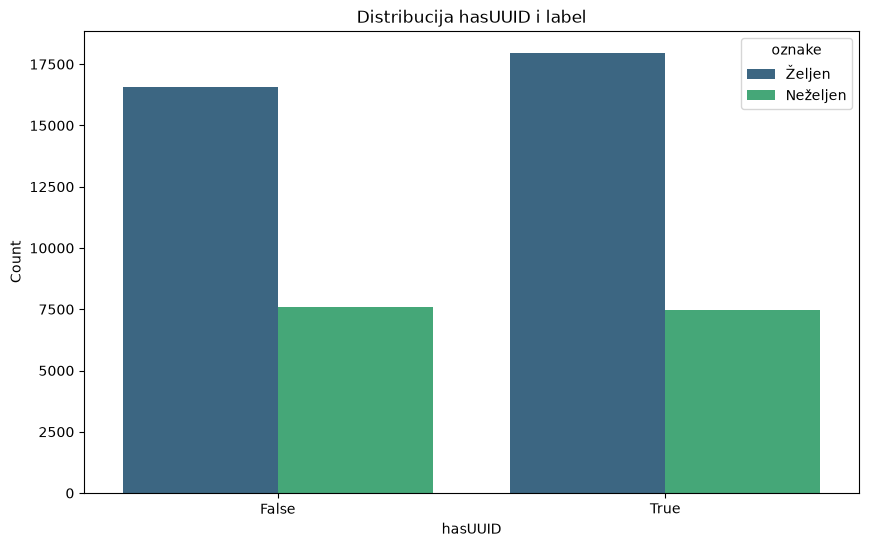

In [74]:
show_categ_graph("hasUUID", "label")

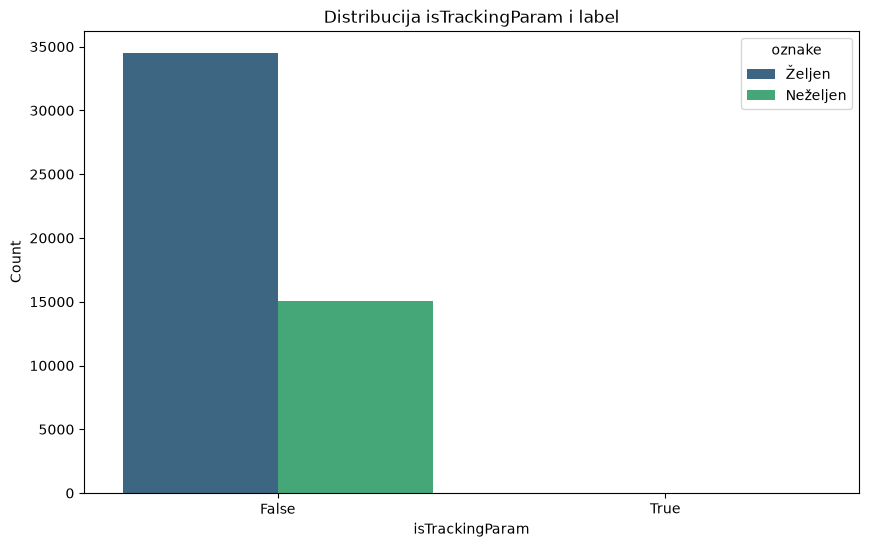

In [75]:
show_categ_graph("isTrackingParam", "label")

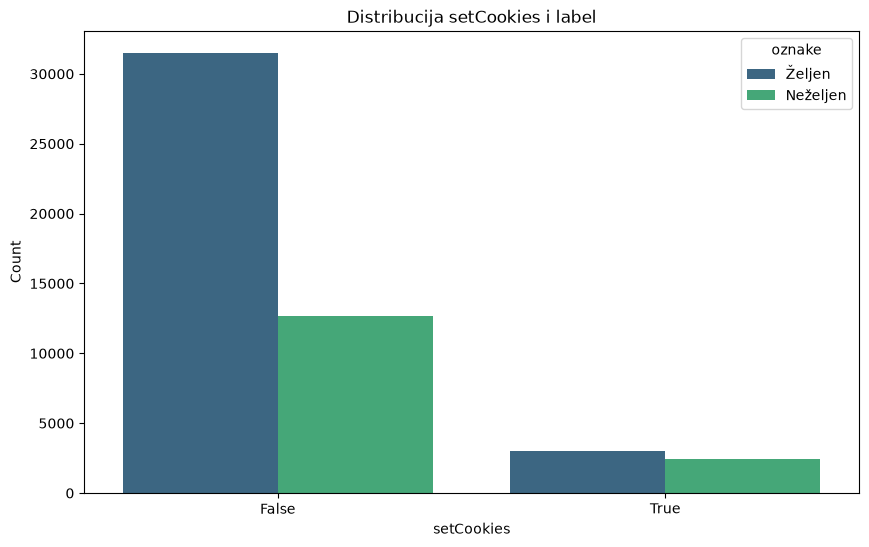

In [76]:
show_categ_graph("setCookies", "label")

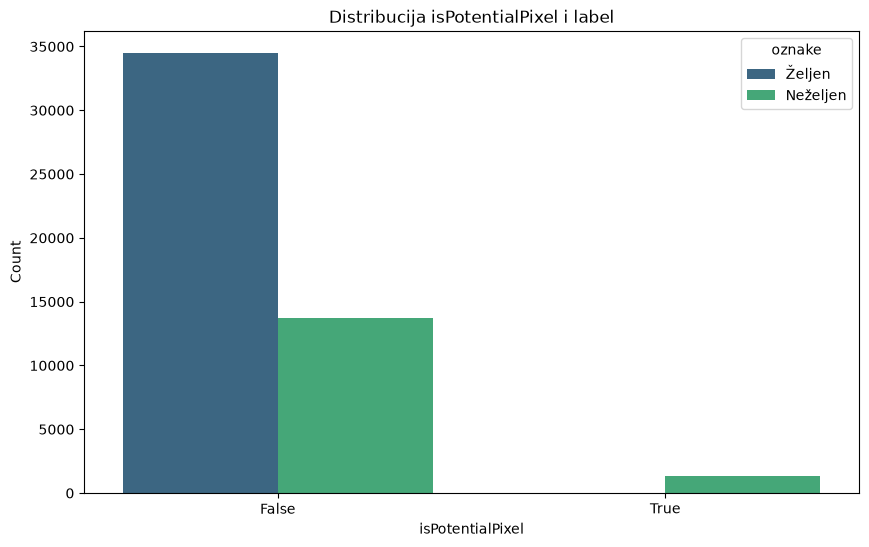

In [77]:
show_categ_graph("isPotentialPixel", "label")

In [82]:
def show_num_graph(el, label):
  sns.displot(df, x=el, hue=label, kind='kde', fill=True)

  plt.xlabel(el)
  plt.ylabel('Density')
  plt.title(f'Distribucija {el} po {label}')
  plt.show()

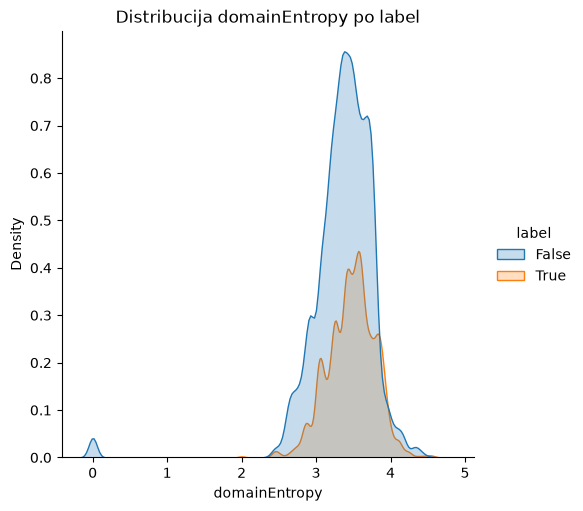

In [83]:
show_num_graph("domainEntropy","label")

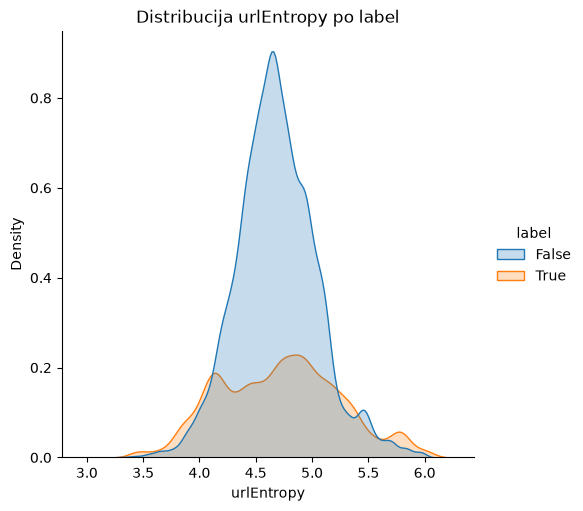

In [84]:
show_num_graph("urlEntropy","label")

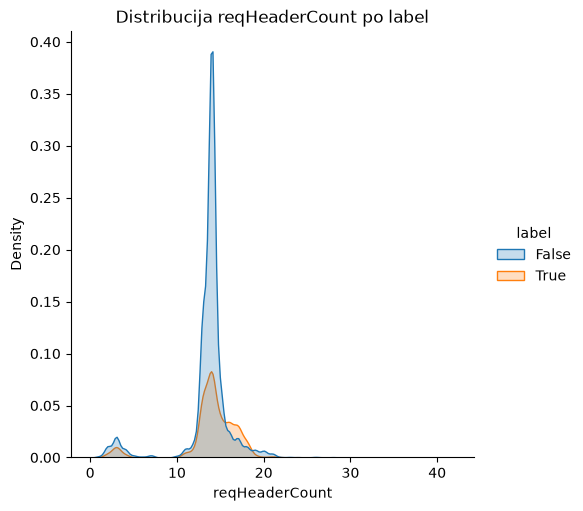

In [85]:
show_num_graph("reqHeaderCount","label")

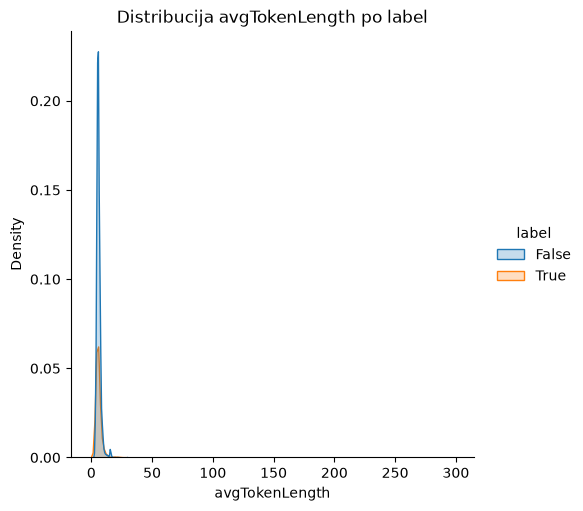

In [86]:
show_num_graph("avgTokenLength","label")

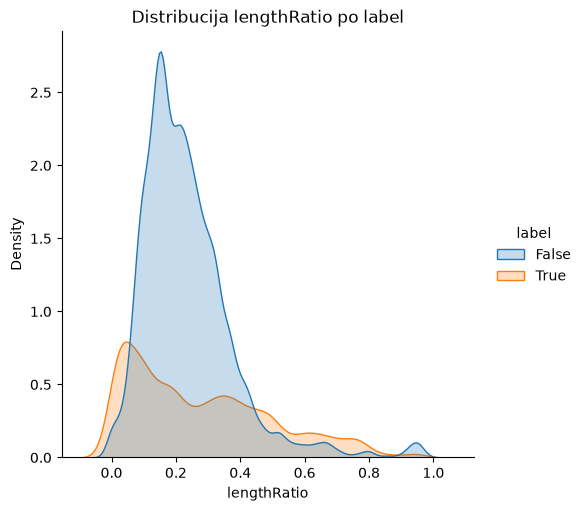

In [87]:
show_num_graph("lengthRatio","label")

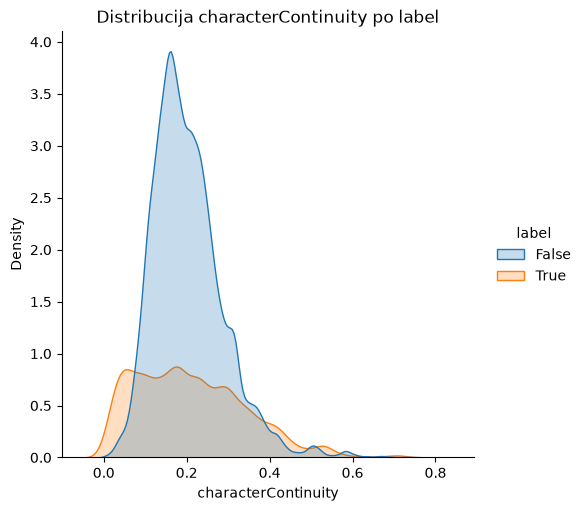

In [88]:
show_num_graph("characterContinuity","label")

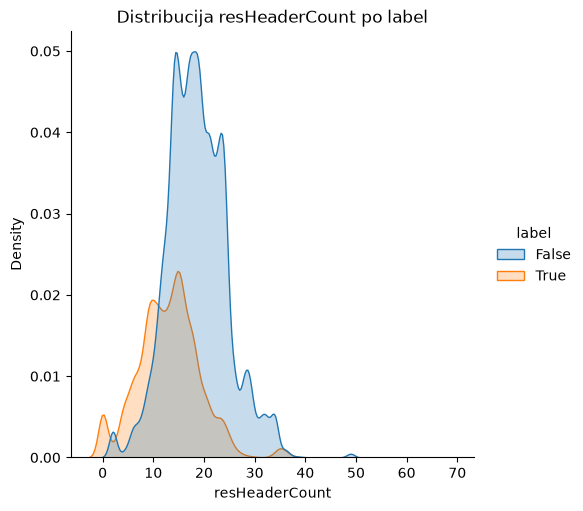

In [90]:
show_num_graph("resHeaderCount","label")

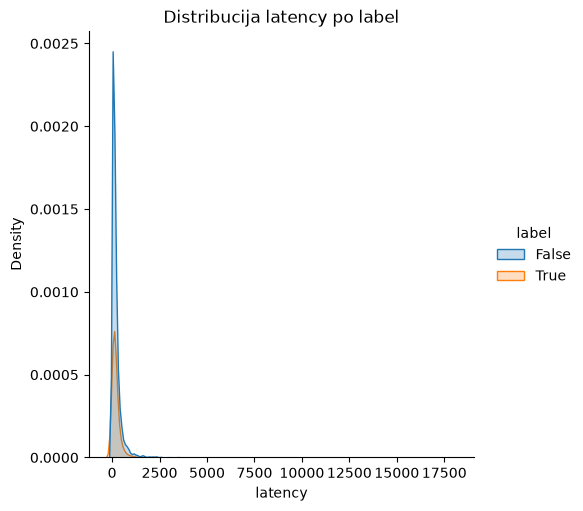

In [91]:
show_num_graph("latency","label")

# **Obrada zahtjeva i odgovora**

Nakon prikaza svih atributa, moguće ih je urediti.

In [17]:
df = pd.read_csv('df_labeled.csv', low_memory=False)

In [92]:
def isThirdParty(url, mainPageUrl):
    main_host = urlparse(mainPageUrl).hostname
    url_host = urlparse(url).hostname
    
    # Ako bilo koji URL nije ispravno parsiran, pretpostavljamo da nije third-party ili preskačemo
    if not main_host or not url_host: 
        return False 
        
    mainPageDomain = main_host.lower()
    urlDomain = url_host.lower()

    # Logički ispravno: True ako su domene RAZLIČITE (Third Party)
    return mainPageDomain != urlDomain

df["isThirdParty"] = df.apply(lambda row: isThirdParty(row["url"], row["mainPageUrl"]), axis=1)

In [94]:
# Pretvoreno u set radi brze provjere
UNWANTED_HEADERS = {
#other unwanted
    "x-onetrust-isbot", "x-didomi-configs-version", "x-didomi-remote-config-metadata",
    "x-didomi-version", "x-datadome", "x-datadome-cid", "x-dd-b", "x-dd-page-size",
    "bxpunish", "x5-punish-cache", "x-px-blocked", "x-amzn-waf-challenge-id",
    "x-amzn-waf-action", "cf-chl-out", "cf-chl-gen", "cf-chl-out-s",
    "x-experiment-payload", "x-experiment-tracking", "x-experiment-visitor-id",
    "x-treatment-hash", "x-treatment-ids", "x-treatment-page-hash",
    "x-erf-bev-bev", "x-erf-bev-bev-is-generated", "x-splittest",
    "x-abt-application-version", "statsig-final-byte-size", "x-statsig-region"
#ad
    'x-tbl-io-backend', 'x-tbl-io-error', 'x-amz-meta-x-tbl-source',
    'x-criteo-endpoint-action', 'x-criteo-endpoint-controller', 'x-criteo-endpoint-version',
    'ad-auction-allowed', 'x-spotim-device-uuid', 'x-spotim-bid', 'x-spotim-rid',
    'x-spotim-vid', "bidder", "x-openrtb-version", "x-prebid", "adthrive-bucket",
    "adthrive-commit", "adthrive-deployment", "adthrive-gdpr", "google-creative-id",
    "google-lineitem-id", "google-mediationgroup-id", "google-mediationtag-id",
    "x-begun-impressionid", "x-begun-graphcount", "x-begun-graphprice",
    "x-begun-textcount", "x-begun-textprice", "x-atmtd-floors-created-at",
    "x-atmtd-floors-path", "x-atmtd-floors-source", "allow-fenced-frame-automatic-beacons"
# tracking
    "tracking", "x-pixel-event-id", "x-criteo-endpoint-action", "x-criteo-endpoint-controller",
    "x-criteo-endpoint-version", "observe-browsing-topics", "x-fb-optimizer", "x-reddit-ct",
    "x-hubspot-correlation-id", "x-nyt-audience-target-flat", "x-nyt-mktg-group", "bxuuid",
    "x-tracking-snippet-served-by", "x-nike-visitid", "x-nike-visitorid", "x-airbnb-everest-device-id",
    "x-zm-trackingid", "x-zm-zoneid", "campaign-trace-id", "x-newrelic-app-data", 'x-didomi-version',
    'x-didomi-configs-version', 'x-didomi-remote-config-metadata', 'x-onetrust-isbot',
    'x-fides-version', 'x-logrocket-upload-max-interval', 'x-logrocket-upload-max-size',
    'dotmetrics-hit-status', 'attribution-reporting-register-source',
    'attribution-reporting-register-aggregatable-source', 'spoor-device-id', 'spoor-ticket',
    'x-recombee-request-id', 'x-evergage-beacon-ver', 'x-fb-connection-quality', 'x-fb-debug',
    'x-fb-edge-debug', 'x-fb-ptm-uuid', 'x-pinterest-rid', 'x-pinterest-rid-128bit',
    'pinterest-version', 'x-twitter-response-tags', 'x-hs-request-id', 'x-hs-user-login-state',
    'x-klaviyo-hash', 'x-datadog-trace-id'
#cookie
    'set-cookie', 'cookie', 'x-cached-cookies', 'x-server-cookie',
    'worker-missing-cookies', 'x-as-suppresssetcookie'
}

def extract_header_features(element_headers):
    if not isinstance(element_headers, dict):
        try:
            element_headers = ast.literal_eval(element_headers)
        except (ValueError, SyntaxError, TypeError):
            element_headers = {}

    lowercased_headers = {k.lower() for k in element_headers.keys()}
    features = sum(1 for h in lowercased_headers if h in UNWANTED_HEADERS)

    return features

df["suspiciousResHeaders"] = df['resHeader'].apply(extract_header_features)
df["suspiciousReqHeaders"] = df['reqHeader'].apply(extract_header_features)

In [95]:
# Extract domains for chain analysis
def get_domain(url_str):
    if not url_str: return ""
    try:
        return urllib.parse.urlparse(url_str).netloc
    except:
        return ""

df['domain'] = df['url'].apply(get_domain)
df['initiator_domain'] = df['initiatorUrl'].apply(get_domain)

# 2. Build the Causal Initiator Graph PER PAGE (not globally)
# Each page gets its own network graph to match production behavior
chain_lengths = []
unique_domains_in_chain = []
consecutive_same_domain_counts = []

for page_url, group in df.groupby("mainPageUrl"):
    # Build a separate network graph for this page
    G = nx.DiGraph()
    for _, row in group.iterrows():
        if row["initiatorUrl"]:
            G.add_edge(row["initiatorUrl"], row["url"])
        else:
            G.add_node(row["url"])

    # Calculate chain features for each request on this page
    for _, row in group.iterrows():
        target_node = row["url"]

        # Trace the chain backwards to find the root initiator
        chain = []
        current = target_node
        visited = set()  # Avoid infinite redirect loops

        while current and current in G and current not in visited:
            visited.add(current)
            chain.append(current)
            predecessors = list(G.predecessors(current))
            current = predecessors[0] if predecessors else None

        # Reverse: Root -> ... -> Script -> Target URL
        chain.reverse()

        # Feature A: Length of the chain
        chain_lengths.append(len(chain))

        # Extract domains in this sequential chain
        chain_domains = [get_domain(url) for url in chain if url]

        # Feature B: Number of unique domains in the chain
        unique_domains_in_chain.append(len(set(chain_domains)))

        # Feature C: Consecutive requests to the same domain
        consecutive_count = 0
        for i in range(len(chain_domains) - 1):
            if chain_domains[i] == chain_domains[i+1] and chain_domains[i] != "":
                consecutive_count += 1

        consecutive_same_domain_counts.append(consecutive_count)

# Add the new sequential features to your DataFrame!
df['chain_length'] = chain_lengths
df['unique_domains_in_chain'] = unique_domains_in_chain
df['consecutive_same_domain_track'] = consecutive_same_domain_counts

df.rename(columns={'chain_length': 'chainLength', 'consecutive_same_domain_track': 'consecutiveSameDomainTrack',
                  'unique_domains_in_chain': 'uniqueDomainsInChain'}, inplace=True)
df.drop(columns=["domain", "initiator_domain", "initiatorUrl"], inplace=True)


In [96]:
# Query parametri
def countQueryParams(url):
    query = urlparse(url).query
    if not query:
        return 0
    return len(query.split("&"))

df["queryParamsCount"] = df["url"].apply(countQueryParams)


In [97]:
# hasSizeBytes
def hasSizeBytes(sizeByte):
    try:
        return float(sizeByte) > 0
    except (TypeError, ValueError):
        return False

df["hassizeBytes"] = df["hassizeBytes"].apply(hasSizeBytes)


Atributi izbačeni zbog korelacije unutar skupa podataka, viđeno unutar matrice korelacije

In [99]:
df.drop(columns = ["specialCharCount",
                   "urlTokenCount",
                   "suspiciousSymbols",
                  "isPotentialPixel",
                   "isTrackingParam",
                   "reqHeader",
                   "resHeader",
                   "setCookies",
                   "domSubtreeSize",
                   "url", 
                   #"mainPageUrl",
                   "avgTokenLength",
                   "lengthRatio",
                   "characterContinuity",
                   "reqHeaderCount",
                   "resHeaderCount"
                   ], inplace= True)

Uređivanje atributa koji su previše iskrivljeni

In [100]:
# log(1 + x) da bismo izbjegli log(0)
df['latency'] = np.log1p(df['latency'])
df['urlLength'] = np.log1p(df['urlLength'])
df['queryParamsCount'] = np.log1p(df['queryParamsCount'])

Uređivanje MimeType

In [101]:
def cleanMime (mime):
    if not mime:
        return 'unknown'

    if pd.isna(mime):
        return 'unknown'
    return str(mime).lower().split(';')[0].strip()

df['mimeType'] = df['mimeType'].str.lower()
df['mimeType'] = df['mimeType'].apply(lambda x: x.split(';')[0].strip() if pd.notna(x) and ';' in x else x)

In [102]:
def categorize_mime(mime):
    m = str(mime).lower()

    if "script" in m or "sacript" in m:
        return "javascript"
    if "image" in m or "jpg" in m:
        return "image"
    if "font" in m or "woff" in m:
        return "font"
    if "json" in m:
        return "json"
    if "xml" in m:
        return "xml"
    if "icon" in m:
        return "icon"
    if "binary" in m or "octet" in m:
        return "binary"
    if "video" in m or "mpeg" in m:
        return "video"
    if "text/html" in m:
        return "html"
    if "text/css" in m:
        return "css"

    return "unknown"

df['mimeType'] = df['mimeType'].apply(categorize_mime)

In [103]:
def categorize_method(method):
  m =str(method).lower()
  if m =="get" or m=="post": return method
  else: return "other"

df["method"] = df["method"].apply(categorize_method)

In [104]:
# Status
def categorize_status(status):
    if status is None or np.isnan(status) or status == 0:
        return "Failed_Connection"

    status = int(status)

    if status == 200 or status == 204:
        return "Success_OK"
    elif status in [201, 202]:
        return "Success_Created"
    elif 200 <= status < 300:
        return "Success_Other"
    elif status >= 300 and status < 400: return "Redirects"
    elif status >= 400 and status < 500: return "Error_user"
    else: return "Error_server"

df["status"] = df["status"].apply(categorize_status)

In [27]:
# Initiator Type
def categorize_initiator(initiator):
  allow_list = ["other", "parser", "script", "preflight"]
  if initiator in allow_list: return initiator
  else: return "unknown"

df["initiatorType"] = df["initiatorType"].apply(categorize_initiator)

In [28]:
df.loc[df["consecutiveSameDomainTrack"] >=3, "consecutiveSameDomainTrack"] = 3
df.loc[df["uniqueDomainsInChain"] >=4 , "uniqueDomainsInChain"] = 4
df.loc[df["chainLength"] >=6, "chainLength"] = 6
df.loc[df["directDomConnections"] >=3, "directDomConnections"] = 3
df.loc[df["suspiciousResHeaders"] >=1, "suspiciousResHeaders"] = 1
df.loc[df["suspiciousReqHeaders"] >=1, "suspiciousReqHeaders"] = 1

In [107]:
df.to_csv('final_df.csv', index=False)

# **Vizualizacija podataka nakon pripreme podataka**

In [214]:
numericalCols = df.select_dtypes(include=['number']).columns.tolist()

In [215]:
cols = df.columns.tolist()
categCols = []

for i in cols:
  if i not in numericalCols:
    categCols.append(i)

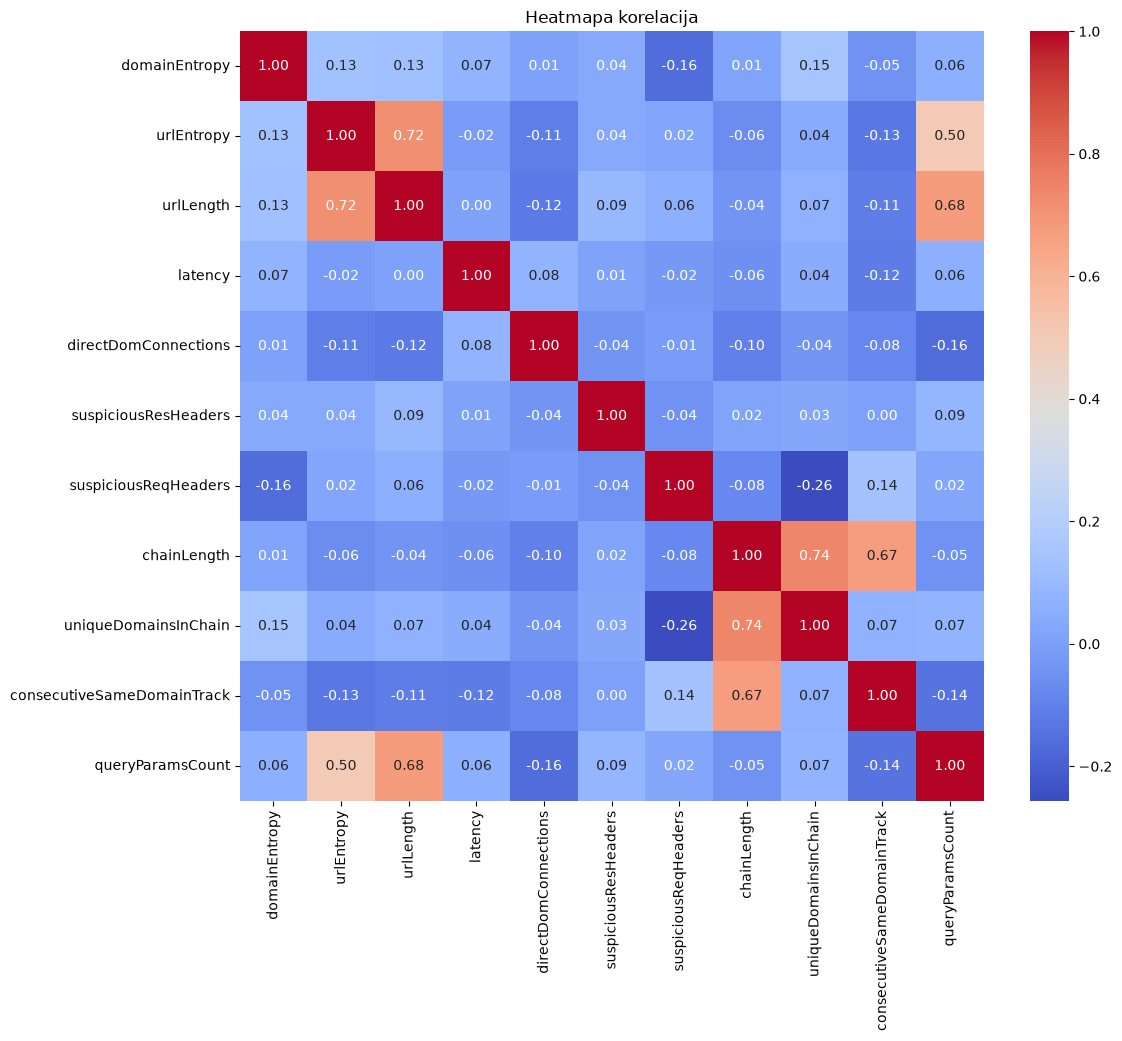

In [216]:
correlation_matrix = df[numericalCols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmapa korelacija")
plt.show()

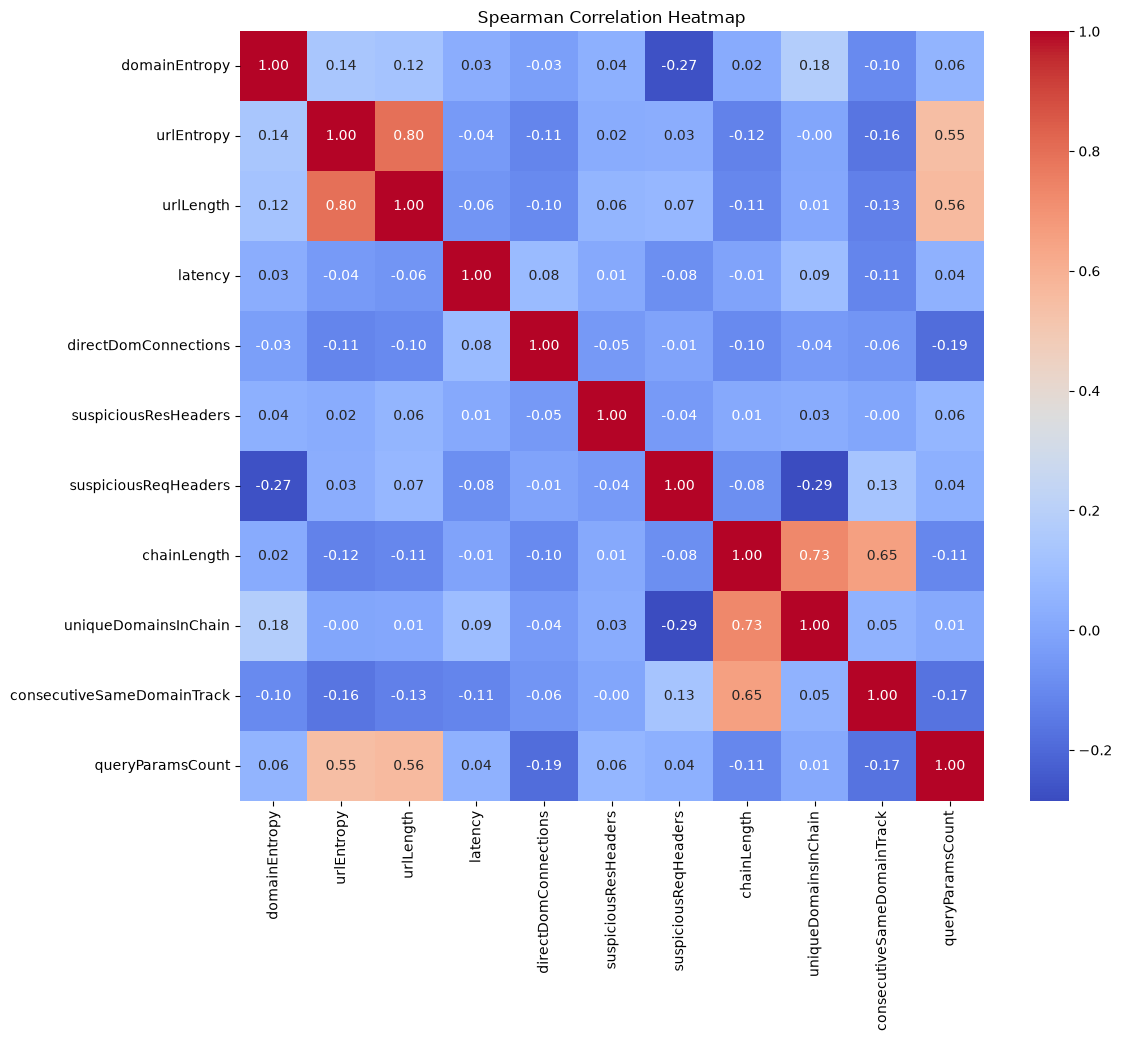

In [217]:
correlation_matrix = df[numericalCols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

### Kategorički atributi

In [218]:
def show_categ_graph(el, label):
  plt.figure(figsize=(10, 6))
  sns.countplot(data=df, x=el, hue=label, palette='viridis')
  plt.title(f'Distribucija {el} i {label}')
  plt.xlabel(el)
  plt.ylabel('Count')
  plt.legend(title='oznake', labels=['Željen', 'Neželjen'])
  plt.show()

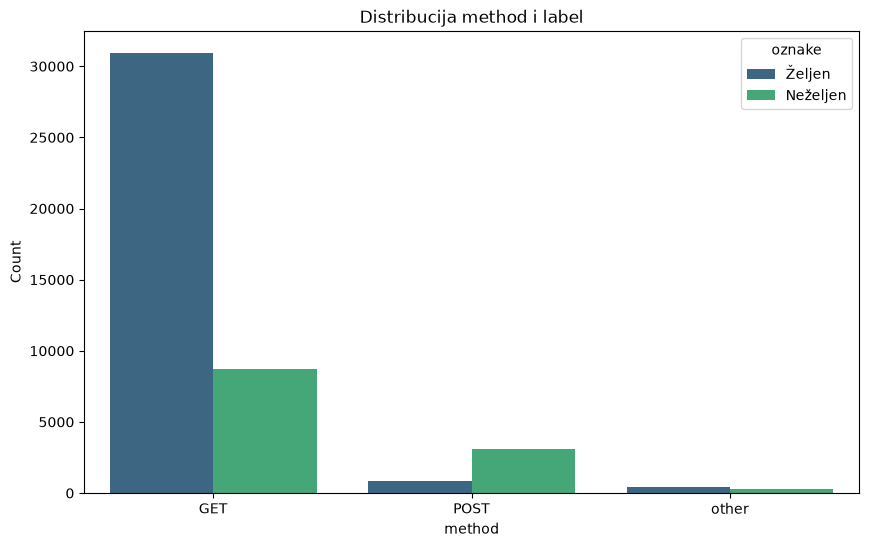

In [178]:
show_categ_graph("method", "label")

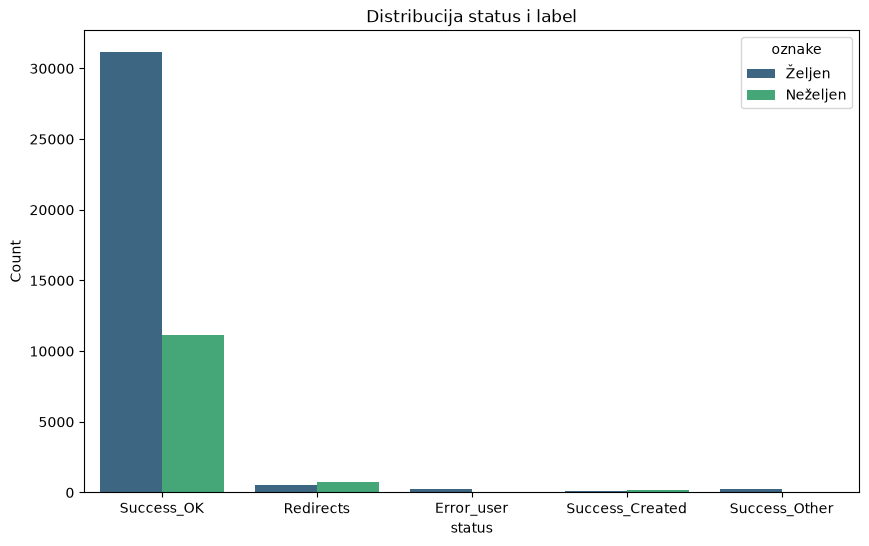

In [179]:
show_categ_graph("status", "label")

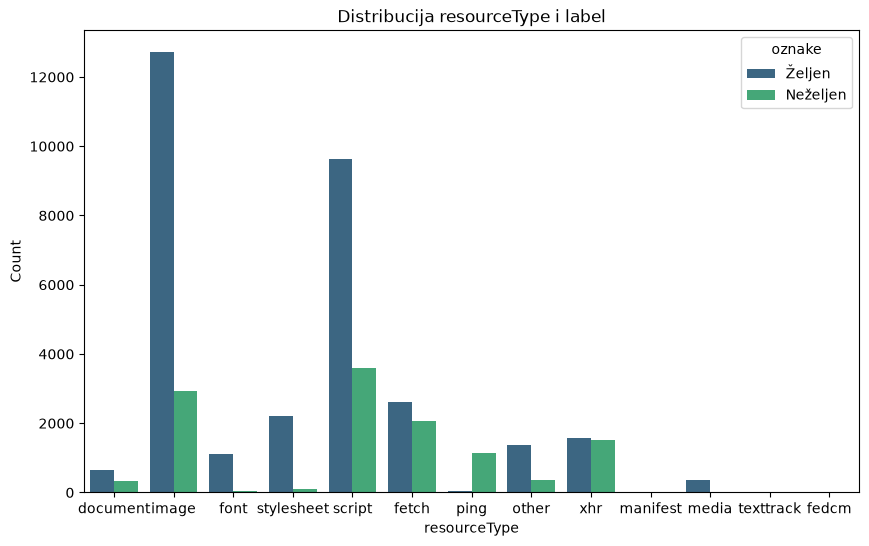

In [180]:
show_categ_graph("resourceType", "label")

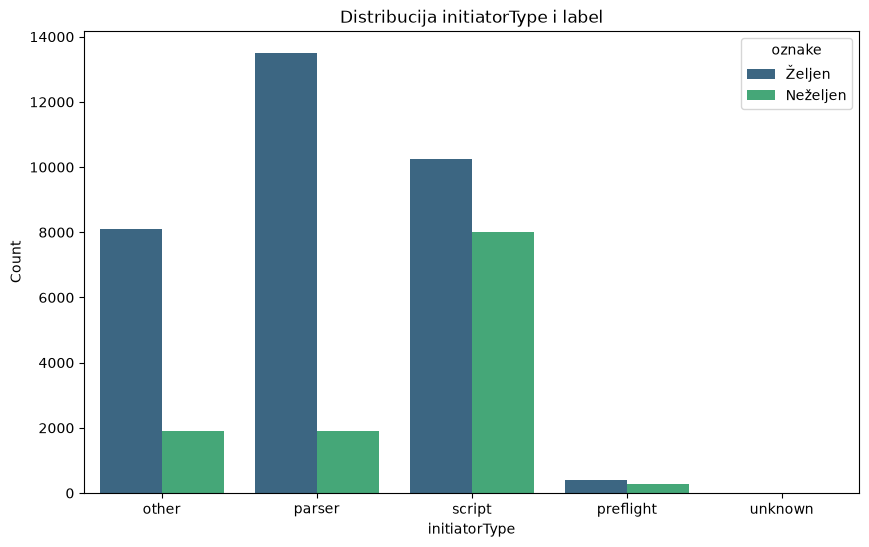

In [181]:
show_categ_graph("initiatorType", "label")

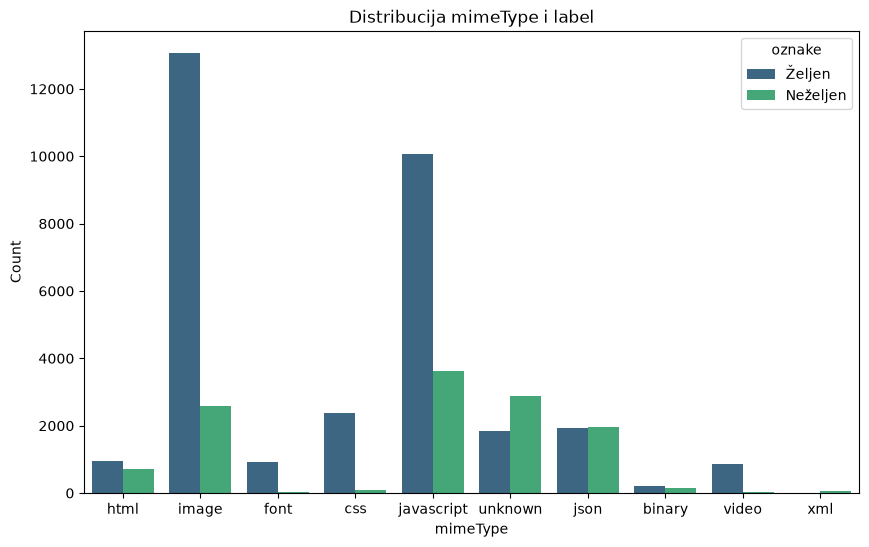

In [182]:
show_categ_graph("mimeType", "label")

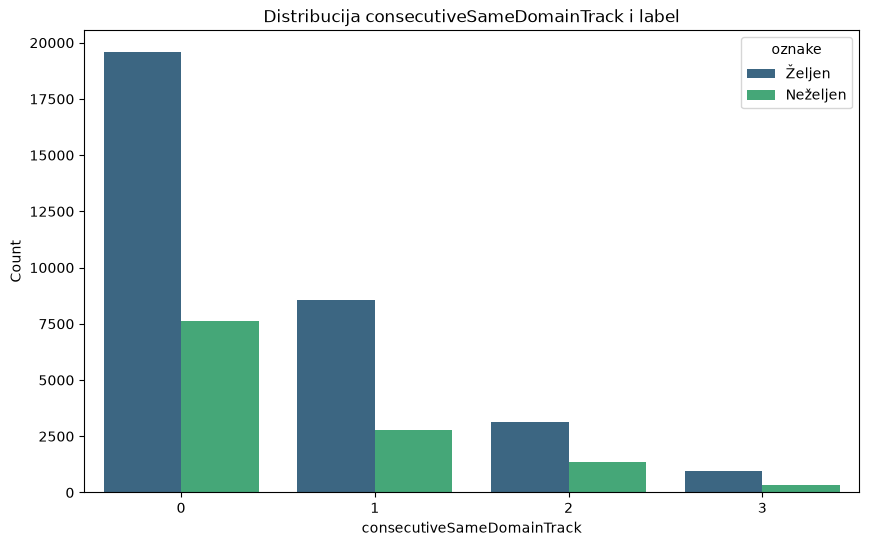

In [183]:
show_categ_graph("consecutiveSameDomainTrack", "label")

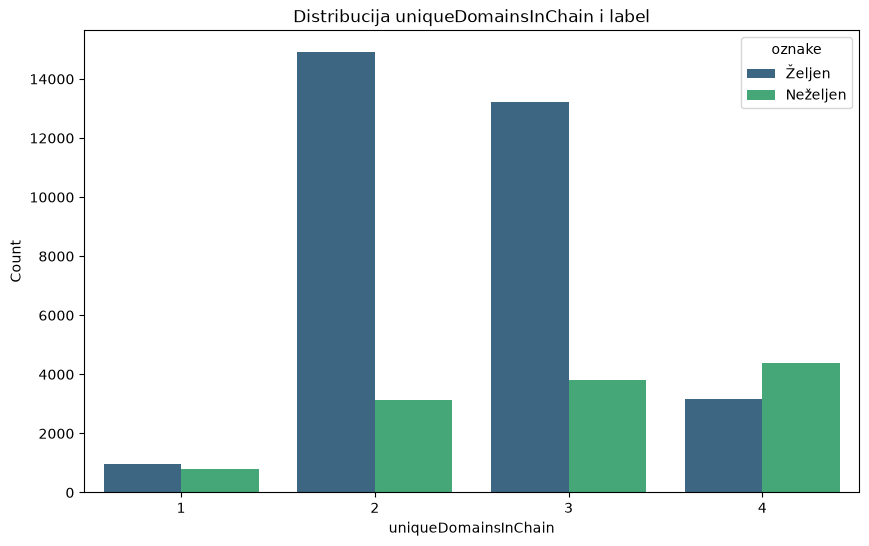

In [184]:
show_categ_graph("uniqueDomainsInChain", "label")

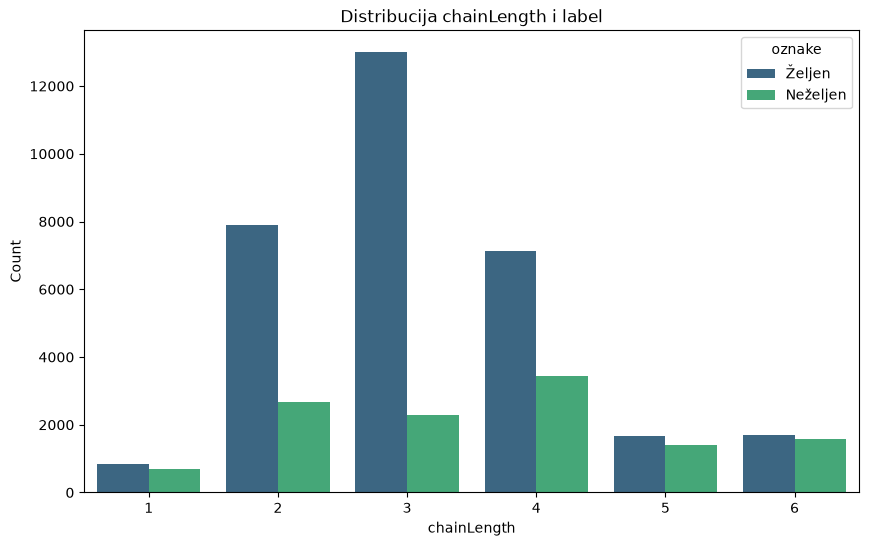

In [185]:
show_categ_graph("chainLength", "label")

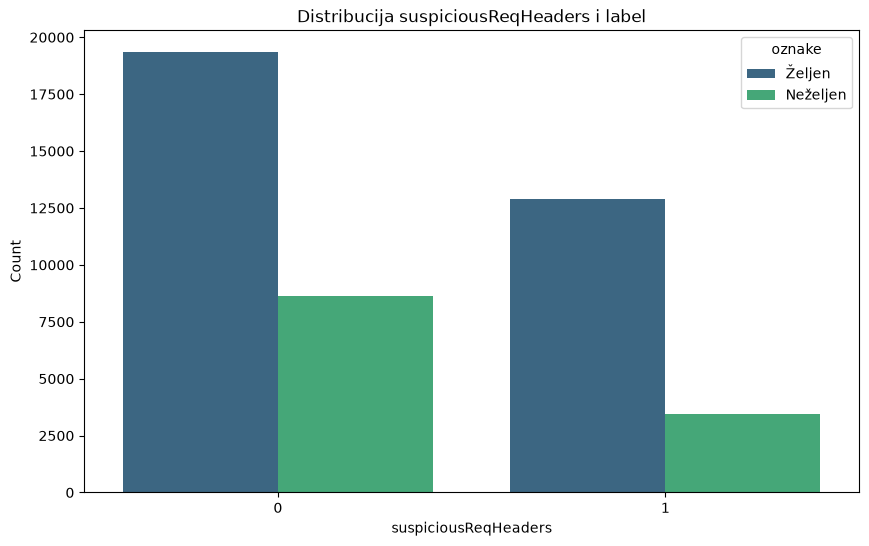

In [219]:
show_categ_graph("suspiciousReqHeaders", "label")

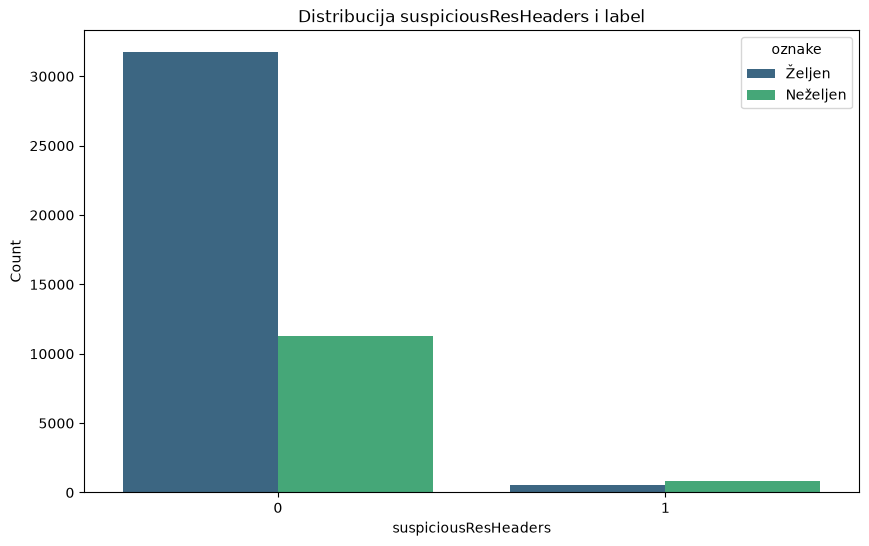

In [220]:
show_categ_graph("suspiciousResHeaders", "label")

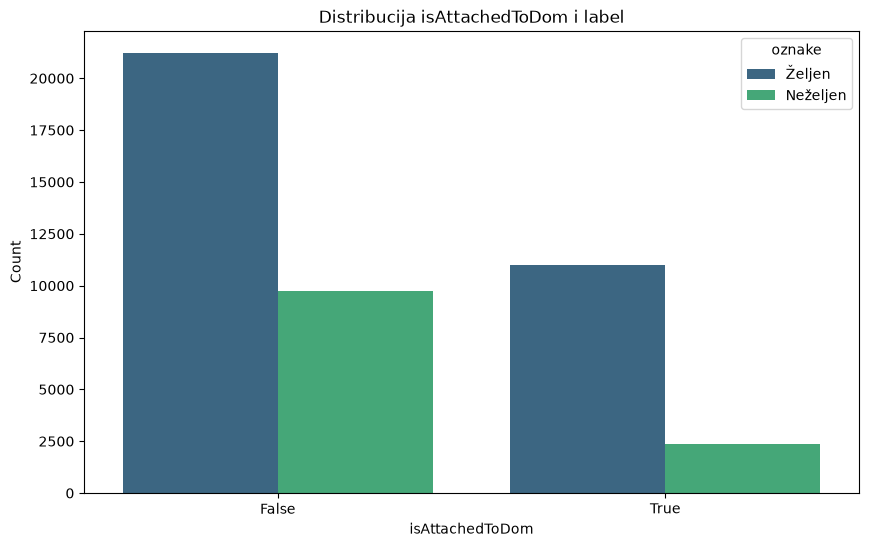

In [188]:
show_categ_graph("isAttachedToDom", "label")

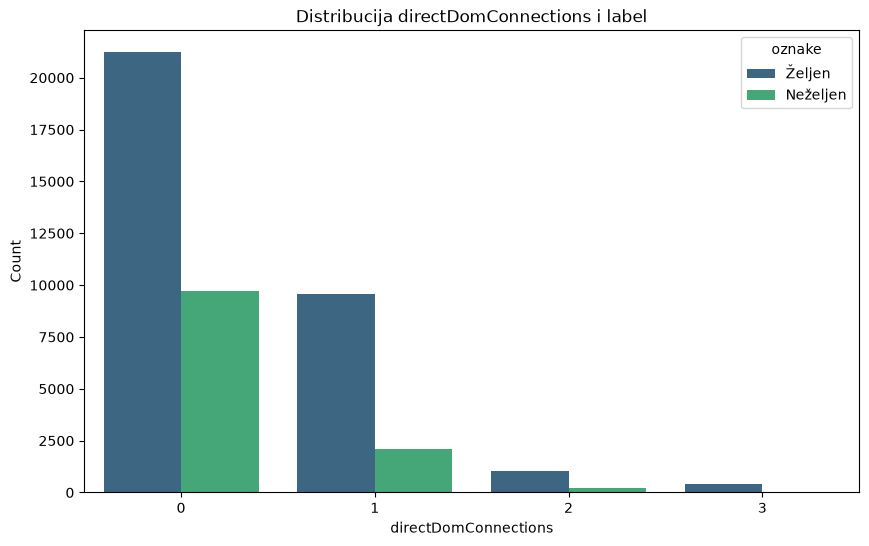

In [189]:
show_categ_graph("directDomConnections", "label")

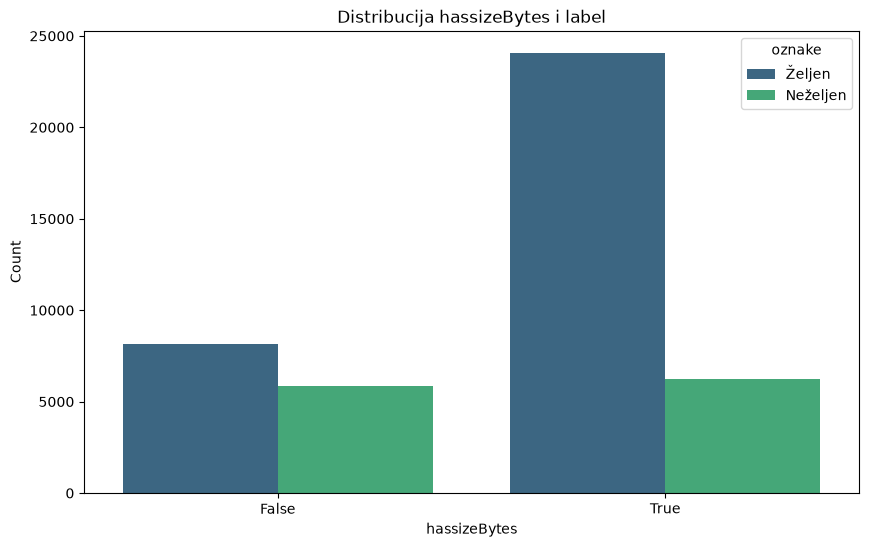

In [190]:
show_categ_graph("hassizeBytes", "label")

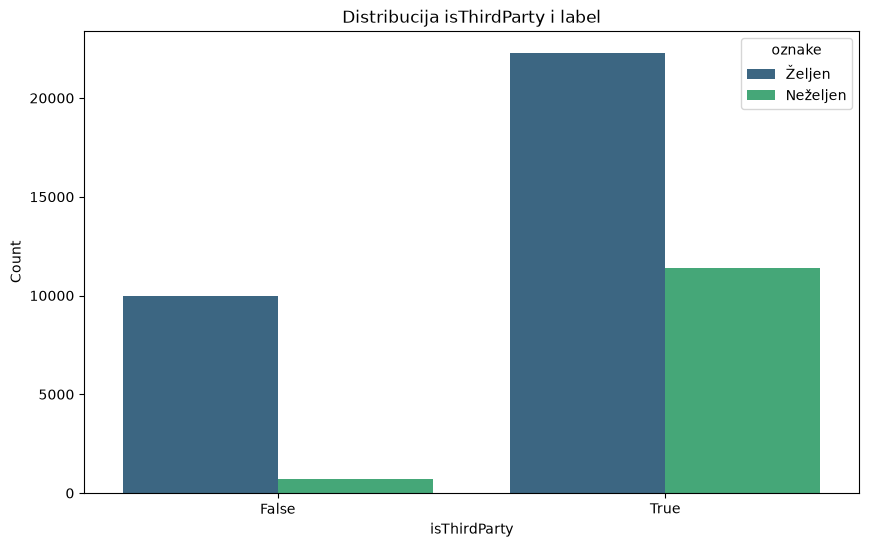

In [191]:
show_categ_graph("isThirdParty", "label")

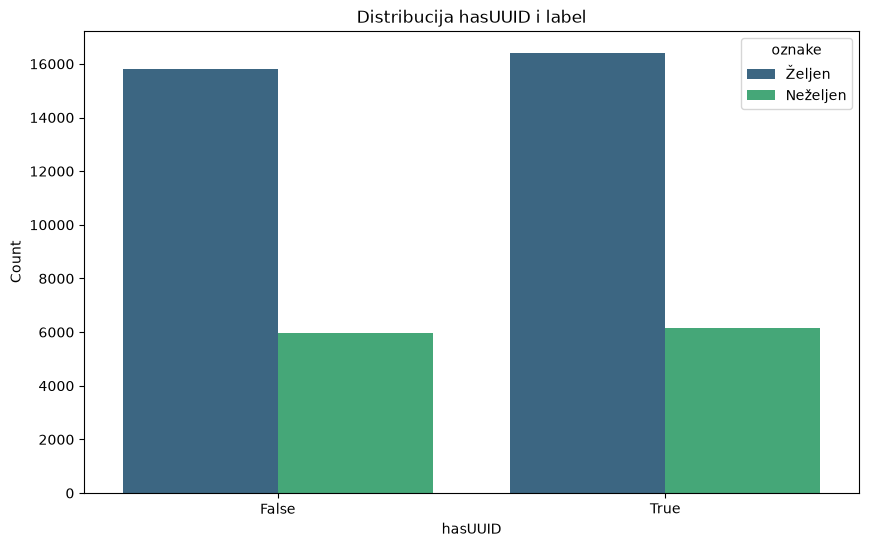

In [192]:
show_categ_graph("hasUUID", "label")

### Numerički podaci

In [221]:
def show_num_graph(el, label):
  sns.displot(df, x=el, hue=label, kind='kde', fill=True)

  plt.xlabel(el)
  plt.ylabel('Density')
  plt.title(f'Distribucija {el} po {label}')
  plt.show()

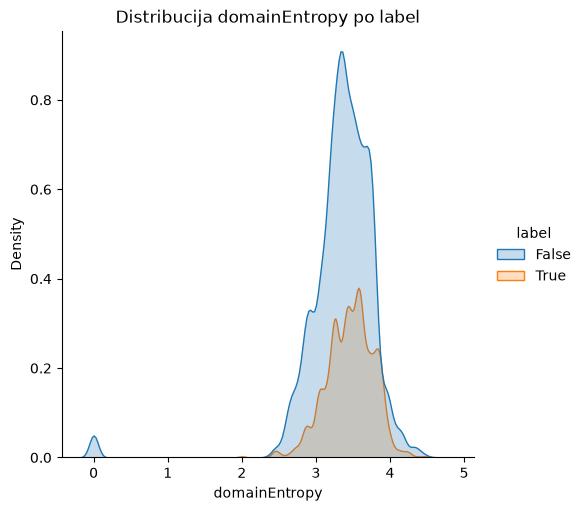

In [195]:
show_num_graph("domainEntropy","label")

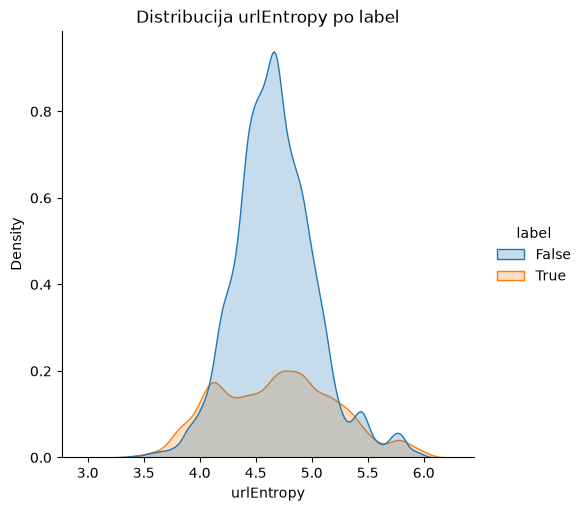

In [196]:
show_num_graph("urlEntropy","label")

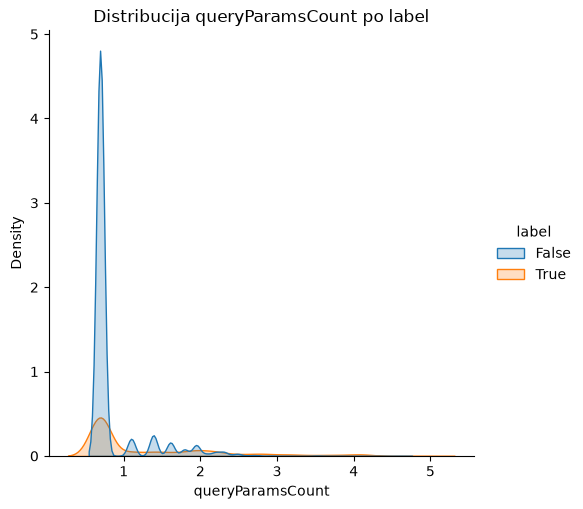

In [222]:
show_num_graph("queryParamsCount","label")

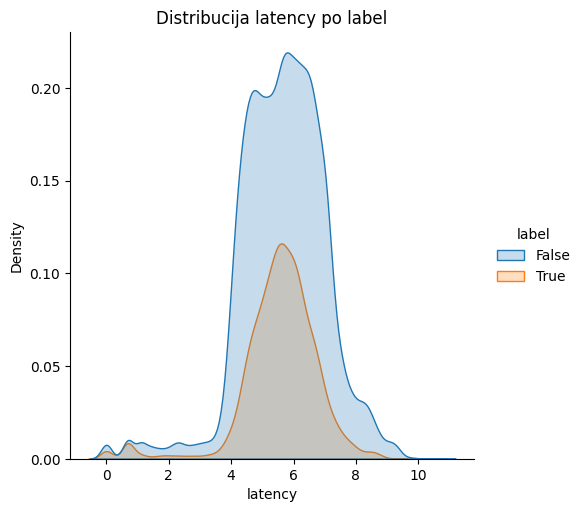

In [ ]:
show_num_graph("latency","label")

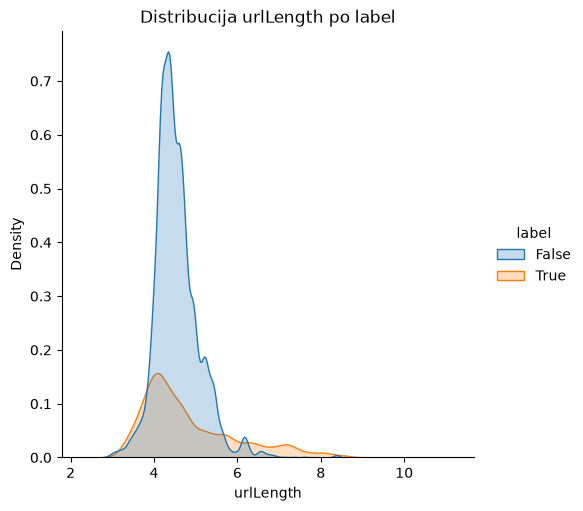

In [223]:
show_num_graph("urlLength","label")

# **Model**

## Izrada i trening podataka

In [30]:
df = pd.read_csv('final_df.csv', low_memory=False)

In [108]:
df.head(2).T

,0,1
mainPageUrl,https://wordpress.org/,https://wordpress.org/
method,GET,GET
resourceType,document,image
initiatorType,other,parser
domainEntropy,3.026987,2.947703
urlEntropy,3.538311,4.616699
isThirdParty,False,True
hasUUID,False,False
urlLength,3.135494,4.290459
status,Success_OK,Success_OK


In [109]:
categCols = [
    "method", "resourceType", "initiatorType", "isThirdParty", "hasUUID", "status", "mimeType", "hassizeBytes", 
    "isAttachedToDom", "label"
]

numericalCols = [
    "domainEntropy", "urlLength", "urlEntropy", 'latency'
]

In [110]:
label_encoders = {}
for col in categCols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [111]:
X, y = df.drop(columns=['label']), df['label']

In [112]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.model_selection import GroupShuffleSplit

# Split by mainPageUrl so whole websites stay either entirely in Train or entirely in Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=df['mainPageUrl']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train.drop(columns=["mainPageUrl"], inplace=True)
X_test.drop(columns=["mainPageUrl"], inplace=True)

In [113]:
scaler = RobustScaler()

X_train_numerical = X_train[numericalCols]
X_test_numerical = X_test[numericalCols]

X_train_scaled = scaler.fit_transform(X_train_numerical)
X_test_scaled = scaler.transform(X_test_numerical)

X_train[numericalCols] = X_train_scaled
X_test[numericalCols] = X_test_scaled

In [114]:
centers = scaler.center_
scales = scaler.scale_

scaling_map = dict(zip(numericalCols, zip(centers, scales)))

for col, (center, scale) in scaling_map.items():
    print(f"Column: {col} | Median: {center} | IQR: {scale}")

Column: domainEntropy | Median: 3.447401504705915 | IQR: 0.4619722951211731
Column: urlLength | Median: 4.454347296253507 | IQR: 0.7308875085427928
Column: urlEntropy | Median: 4.66675038054775 | IQR: 0.5079426631904482
Column: latency | Median: 4.653960350157523 | IQR: 1.711716761554519


## Treniranje modela


Random search se koristi radi bržeg pronalaska boljih parametara. 

### kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='minkowski',
        p=2,
        n_jobs=-1
    )

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_scores.append(scores.mean())

# Najbolji k
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Best k: {best_k}")
print(f"Best CV ROC-AUC: {best_score:.4f}")

# Graf
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Broj susjeda (k)')
plt.ylabel('Prosječni ROC-AUC (5-fold CV)')
plt.title('Utjecaj broja susjeda na KNN performanse')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2, 3]
}

model_knn = KNeighborsClassifier(
    n_jobs=-1,
    n_neighbors=5
)

knn_search = RandomizedSearchCV(
    estimator=model_knn,
    param_distributions=param_grid_knn,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

knn_search.fit(X_train, y_train)

best_knn = random_search_knn.best_estimator_

print("Best parameters:", knn_search.best_params_)
print("Best ROC-AUC:", knn_search.best_score_)

In [ ]:
y_train_pred_knn = best_knn.predict(X_train)
y_test_pred_knn = best_knn.predict(X_test)

y_train_proba = best_knn.predict_proba(X_train)[:, 1]
y_test_proba = best_knn.predict_proba(X_test)[:, 1]

print("=== TRAINING SET PERFORMANCE ===")
print(classification_report(y_train, y_train_pred_knn, digits=3))
print("ROC-AUC:", roc_auc_score(y_train, y_train_proba))

print("\n=== TESTING SET PERFORMANCE ===")
print(classification_report(y_test, y_test_pred_knn, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['wanted', 'unwanted'])
disp.plot()
plt.show()

### SVM

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],                        # regularization, same as LR
    'kernel': ['rbf', 'sigmoid'], # decision boundary shape
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],  # only used for rbf, poly, sigmoid
    'degree': [2, 3, 4],                            # only used when kernel='poly'
    'class_weight': ['balanced', None],             # handles imbalanced data
    'coef0': [0.0, 0.1, 0.5]                        # only used for poly and sigmoid
}

model_svm = SVC(
    random_state=42,
    probability=True,       # needed for probability scores, slightly slower
    cache_size=1000         # more cache = faster training, in MB
)

svm_search = RandomizedSearchCV(
    estimator=model_svm,
    param_distributions=param_grid,
    n_iter=30,              # keep low — SVM is much slower to train than XGB/LR
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_

print("Best parameters:", svm_search.best_params_)
print("Best ROC-AUC:", svm_search.best_score_)

print("=== BEST LOG REG HYPERPARAMETERS ===")
print(svm_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
y_train_pred_svm = best_svm.predict(X_train)
y_test_pred_svm = best_svm.predict(X_test)

y_train_proba = best_svm.predict_proba(X_train)[:, 1]
y_test_proba = best_svm.predict_proba(X_test)[:, 1]

print("=== SVM: TRAINING SET PERFORMANCE ===")
print(classification_report(y_train, y_train_pred_svm, digits=3))
print("ROC-AUC:", roc_auc_score(y_train, y_train_proba))

print("\n=== SVM: TESTING SET PERFORMANCE ===")
print(classification_report(y_test, y_test_pred_svm, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

In [ ]:
cm = confusion_matrix(y_test, y_test_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['wanted', 'unwanted'])
disp.plot()
plt.show()

### Logistička regresija

In [39]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],          # inverse of regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],          # regularization type
    'solver': ['saga'],                              # saga supports all penalties
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],         # only used when penalty='elasticnet'
    'max_iter': [1000, 2000, 5000],                  # needs more iterations than default
    'class_weight': ['balanced', None]               # handles imbalanced tracker/non-tracker
}

model_lr = LogisticRegression(
    random_state=42,
)

lr_search = RandomizedSearchCV(
    estimator=model_lr,
    param_distributions=param_grid,
    n_iter=50,                  # fewer than XGB since simpler model
    scoring='roc_auc',          # keep same metric for fair comparison
    cv=5,
    n_jobs=-1,                  # LR is CPU only, can use all cores unlike XGB
    verbose=1,
    random_state=42
)

lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_

print("=== BEST LOG REG HYPERPARAMETERS ===")
print(lr_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\Marta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Marta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Marta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.3. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== BEST LOG REG HYPERPARAMETERS ===
{'solver': 'saga', 'penalty': 'l1', 'max_iter': 5000, 'l1_ratio': 0.3, 'class_weight': 'balanced', 'C': 0.1}


In [40]:
y_train_pred_lr = best_lr.predict(X_train)
y_test_pred_lr = best_lr.predict(X_test)
y_pred = best_lr.predict(X_test)

print("=== TRAINING SET PERFORMANCE ===")
print(classification_report(y_train, y_train_pred_lr, digits=3))

print("\n=== TESTING SET PERFORMANCE ===")
print(classification_report(y_test, y_test_pred_lr, digits=3))

=== TRAINING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.914     0.815     0.862     24792
           1      0.627     0.802     0.703      9608

    accuracy                          0.811     34400
   macro avg      0.770     0.808     0.783     34400
weighted avg      0.834     0.811     0.817     34400


=== TESTING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.926     0.838     0.880      6912
           1      0.674     0.833     0.745      2783

    accuracy                          0.837      9695
   macro avg      0.800     0.835     0.812      9695
weighted avg      0.853     0.837     0.841      9695



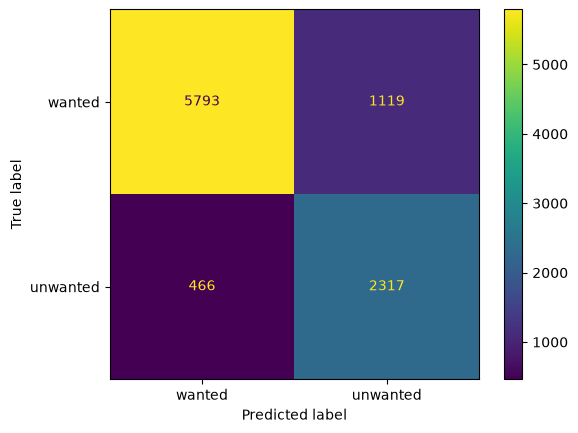

In [41]:
cm = confusion_matrix(y_test, y_test_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['wanted', 'unwanted'])
disp.plot()
plt.show()

### XGBoost

In [121]:
param_grid = {
    'learning_rate': [0.05, 0.07, 0.1], 
    'colsample_bytree' : [0.2, 0.3, 0.5],
    'max_depth': [3, 4, 5],
    'min_child_weight': [5, 7, 10],
    'subsample': [0.5, 0.7, 0.8],
    'min_split_loss': [0.2, 0.3],
    "colsample_bylevel": [0.3, 0.5],
    "colsample_bynode": [0.3, 0.5],
    "reg_lambda": [5, 7, 10]
}

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model_xgb = xgb.XGBClassifier(
    random_state=42, 
    device='cpu', 
    tree_method='hist', # za uštedu GPU-a
    #scale_pos_weight=scale_pos_weight,
    #objective="binary:hinge", #https://xgboosting.com/configure-xgboost-binaryhinge-objective/
    #sampling_method="gradient_based"
)

xgb_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=70,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,          # Prevents multiple processes from fighting for GPU VRAM
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("=== BEST XGB HYPERPARAMETERS ===")
print(xgb_search.best_params_)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
=== BEST XGB HYPERPARAMETERS ===
{'subsample': 0.8, 'reg_lambda': 5, 'min_split_loss': 0.3, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.07, 'colsample_bytree': 0.5, 'colsample_bynode': 0.5, 'colsample_bylevel': 0.5}


In [122]:
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)
y_test_pred_xgb = best_xgb.predict(X_test)

print("=== XGBOOST: TRAINING SET PERFORMANCE ===")
print(classification_report(y_train, y_train_pred_xgb, digits=3))

print("\n=== XGBOOST: TESTING SET PERFORMANCE ===")
print(classification_report(y_test, y_test_pred_xgb, digits=3))

=== XGBOOST: TRAINING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.872     0.945     0.907     27414
           1      0.848     0.688     0.760     12155

    accuracy                          0.866     39569
   macro avg      0.860     0.817     0.834     39569
weighted avg      0.865     0.866     0.862     39569


=== XGBOOST: TESTING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.879     0.929     0.903      7105
           1      0.801     0.690     0.741      2932

    accuracy                          0.859     10037
   macro avg      0.840     0.809     0.822     10037
weighted avg      0.856     0.859     0.856     10037



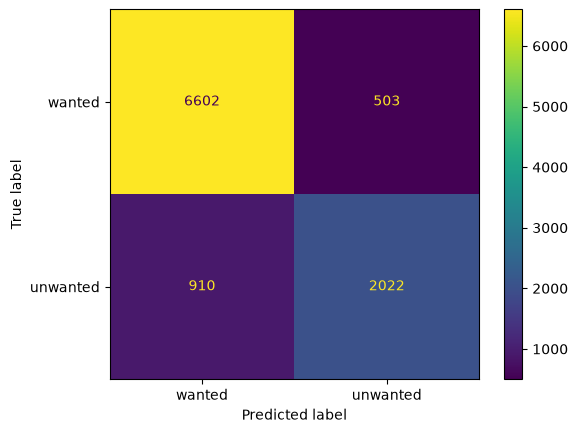

In [123]:
cm = confusion_matrix(y_test, y_test_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['wanted', 'unwanted'])
disp.plot()
plt.show()

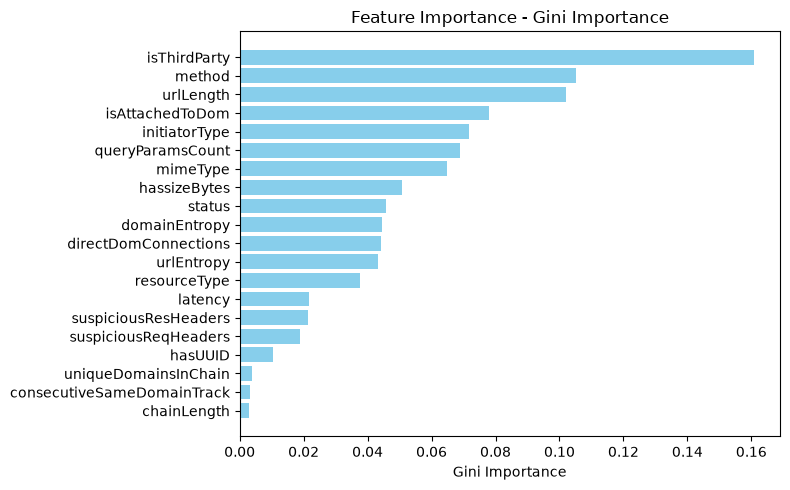

In [124]:
importances = best_xgb.feature_importances_
feature_names = df.drop(columns=["label", "mainPageUrl"]).columns.tolist()
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_df

plt.figure(figsize=(8, 5))
# Pass the sorted columns from feature_imp_df instead of the raw lists
plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')

# Flips the y-axis so index 0 (largest importance) sits at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Random Forest

In [132]:
# 1. Define hyperparameter grid tailored for Random Forest
rf_param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 6, 8, 9],              # niže vrijednosti
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20, 30],     # veći listovi = manje memoriranja
    'max_features': ['sqrt', 'log2', 0.3, 0.4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# 2. Base Model Setup
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring='average_precision',  # PR-AUC focus for Class 1 (Ads/Trackers)
    cv=5,
    n_jobs=-1,                    # Uses all available CPU cores
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("=== BEST RANDOM FOREST HYPERPARAMETERS ===")
print(rf_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
=== BEST RANDOM FOREST HYPERPARAMETERS ===
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.4, 'max_depth': 9, 'class_weight': None}


In [134]:
X_train.columns

Index(['method', 'resourceType', 'initiatorType', 'domainEntropy',
       'urlEntropy', 'isThirdParty', 'hasUUID', 'urlLength', 'status',
       'mimeType', 'hassizeBytes', 'latency', 'directDomConnections',
       'isAttachedToDom', 'suspiciousResHeaders', 'suspiciousReqHeaders',
       'chainLength', 'uniqueDomainsInChain', 'consecutiveSameDomainTrack',
       'queryParamsCount'],
      dtype='str')

In [126]:
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

print("\n=== RANDOM FOREST: TRAINING SET PERFORMANCE ===")
print(classification_report(y_train, y_train_pred_rf, digits=3))

print("\n=== RANDOM FOREST: TESTING SET PERFORMANCE ===")
print(classification_report(y_test, y_test_pred_rf, digits=3))


=== RANDOM FOREST: TRAINING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.908     0.957     0.932     27414
           1      0.889     0.782     0.832     12155

    accuracy                          0.903     39569
   macro avg      0.899     0.869     0.882     39569
weighted avg      0.902     0.903     0.901     39569


=== RANDOM FOREST: TESTING SET PERFORMANCE ===
              precision    recall  f1-score   support

           0      0.901     0.936     0.918      7105
           1      0.828     0.750     0.787      2932

    accuracy                          0.881     10037
   macro avg      0.864     0.843     0.852     10037
weighted avg      0.879     0.881     0.880     10037



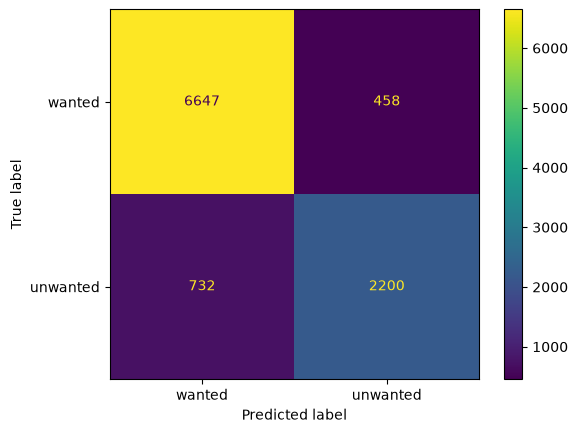

In [127]:
cm = confusion_matrix(y_test, y_test_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['wanted', 'unwanted'])
disp.plot()
plt.show()

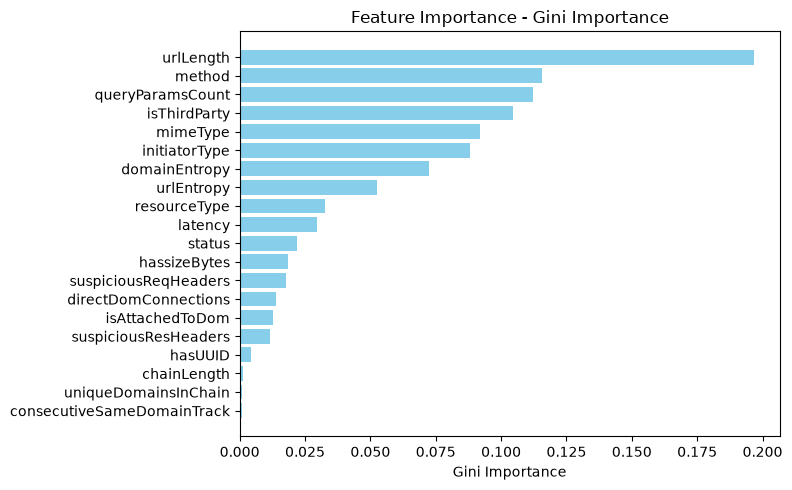

In [128]:
importances = best_rf.feature_importances_
feature_names = df.drop(columns=["label", "mainPageUrl"]).columns.tolist()
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)

plt.figure(figsize=(8, 5))
# Pass the sorted columns from feature_imp_df instead of the raw lists
plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')

# Flips the y-axis so index 0 (largest importance) sits at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Izvoz modela iz okruženja

In [129]:
joblib.dump(best_rf, 'model.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']

In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 15.8 MB/s eta 0:00:00


In [ ]:
import onnxruntime as ort

In [ ]:
predictions = []

session = ort.InferenceSession("xgboost_model.onnx")
input_name = session.get_inputs()[0].name

#ONNX XGB model mora dobiti podatke u određenom redoslijedu
feature_order = [
    'domainEntropy', 'tld', 'subdomainDepth',
    'urlEntropy', 'resourceType', 'setCookies',
    'initiatorType', 'lengthRatio', 'characterContinuity',
    'isThirdParty', 'isPotentialPixel', 'reqHeaderCount',
    'hasUUID', 'status', 'mimeType',
    'avgTokenLength', 'urlLength', 'responseSize',
    'latency'
]

for index, row in X_train.iterrows():
  ordered_data = []
  for el in feature_order:
    ordered_data.append(row[el])
  input_data = np.array(ordered_data, dtype=np.float32).reshape(1, -1)
  outputs = session.run(None, {input_name: input_data})

  prediction = int(outputs[0][0])
  predictions.append(prediction)

# Računamo postotak podataka koji su predviđeni sa "1" (neželjeno)
predicted_unwanted_count = predictions.count(1)
total_generated_samples = len(predictions)
percentage_predicted_unwanted = (predicted_unwanted_count / total_generated_samples) * 100

print(f"Poslano podataka: {total_generated_samples}")
print(f"Broj podataka klasificirano kao '1' (neželjeno): {predicted_unwanted_count}")
print(f"Postotak podataka klasificirano kao '1' (neželjeno): {percentage_predicted_unwanted:.2f}%")

Poslano podataka: 33944
Broj podataka klasificirano kao '1' (neželjeno): 564
Postotak podataka klasificirano kao '1' (neželjeno): 1.66%
